# Faz 13 — cmyLLMz Evaluation

**Ölçülen metrikler:**
1. **Retrieval Hit Rate** — sistem, sorunun cevabını içeren chunk'ları getiriyor mu?
2. **Quality (LLM-as-a-Judge)** — RAG'lı vs RAG'sız cevap kalitesi

**Hakem:** OpenAI gpt-5.4  
**Soru seti:** `data/eval/questions.json` (20 soru)

In [1]:
import os
# GPU'da başka process'ler varsa OOM yaşamamak için embedder'ı CPU'da çalıştır.
# 20 sorgu için CPU 1-2 dakikada biter.
os.environ["EMBEDDER_DEVICE"] = "cpu"

import sys
sys.path.insert(0, '../src')

import json
from pathlib import Path

QUESTIONS_PATH = Path('../data/eval/questions.json')
questions = json.loads(QUESTIONS_PATH.read_text(encoding='utf-8'))
print(f'{len(questions)} soru yüklendi.')

# Tiplere göre dağılım
from collections import Counter
Counter(q['type'] for q in questions)

20 soru yüklendi.


Counter({'cultural': 7, 'humor': 6, 'character': 4, 'timestamp': 3})

---
## 1. Retrieval Testi — Hit Rate

**Ana metrik:** Hit Rate (en az 1 relevant chunk top-k içinde mi?)  
Yardımcı metrikler: Recall@k, Precision@k

In [2]:
from evaluation.retrieval_test import evaluate_retrieval, print_report

retrieval_results = evaluate_retrieval(questions, top_k=5)

# Kaydet
out = Path('../data/eval/results_retrieval.json')
out.write_text(json.dumps(retrieval_results, ensure_ascii=False, indent=2))
print(f'Kaydedildi → {out}')

print_report(retrieval_results)

/home/thwisse/myDesktopL/computerScience/Programming/NLP/cmyllmz/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 29566.64it/s]


Kaydedildi → ../data/eval/results_retrieval.json

  RETRIEVAL TEST SONUÇLARI
  Soru sayısı  : 20
  Top-k        : 5

  Hit Rate     : 100.0%   <- ANA METRİK (en az 1 doğru chunk geldi mi?)
  Recall@k     : 76.4%   (relevant'lerin yüzde kaçı geldi?)
  Precision@k  : 17.3%   (bilgilendirici; tek-chunk sorularda doğal olarak düşük)

  Tipe göre:
    timestamp     hit=100.0%  precision=12.5%  (n=3)
    cultural      hit=100.0%  precision=21.3%  (n=7)
    character     hit=100.0%  precision=13.0%  (n=4)
    humor         hit=100.0%  precision=18.0%  (n=6)

  Başarısız sorular (hit=False):
    Yok — tüm sorularda en az 1 ilgili chunk bulundu.



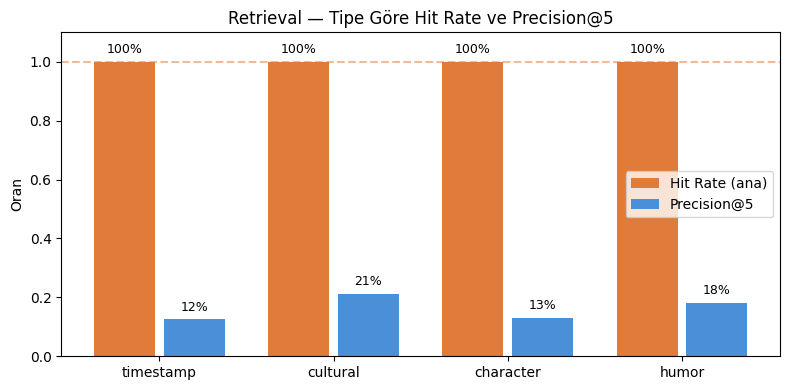

In [3]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Tipe göre Hit Rate (ana metrik) + Precision (yardımcı)
by_type = retrieval_results['by_type']
types = list(by_type.keys())
hit_rates = [by_type[t]['hit_rate'] for t in types]
precisions = [by_type[t]['avg_precision'] for t in types]

x = range(len(types))
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([i - 0.2 for i in x], hit_rates, width=0.35, label='Hit Rate (ana)', color='#e07b39')
bars2 = ax.bar([i + 0.2 for i in x], precisions, width=0.35, label='Precision@5', color='#4a90d9')
ax.set_xticks(list(x))
ax.set_xticklabels(types)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Oran')
ax.set_title('Retrieval — Tipe Göre Hit Rate ve Precision@5')
ax.legend()
ax.axhline(retrieval_results['hit_rate'], color='#e07b39', linestyle='--', alpha=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.0%}", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.0%}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
# Başarısız sorgular — hangi sorularda doğru chunk gelmedi?
failures = [r for r in retrieval_results['per_question'] if not r['hit']]
print(f'Hit rate: {retrieval_results["hit_rate"]:.1%} — {len(failures)} soru başarısız\n')
for f in failures:
    print(f"[{f['id']}] {f['question']}")
    print(f"  Beklenen : {f['relevant']}")
    print(f"  Gelen    : {f['retrieved']}")
    print()

Hit rate: 100.0% — 0 soru başarısız



---
## 2. Quality Testi — LLM-as-a-Judge

**Uyarı:** Her soru için 3 LLM çağrısı yapılır (RAG cevabı + No-RAG cevabı + gpt-5.4 hakemi).  
20 soruda toplam ~60 API çağrısı. Maliyet: ~$0.40 (gpt-5.4 hakem + gpt-5.4-mini RAG/no-RAG).

OpenAI API key'i `openai_client.py` içinde tanımlı, ekstra env değişkeni gerekmez.

In [5]:
# Sadece birkaç soruyla test et (full run için aşağıdaki hücreyi kullan)
from evaluation.quality_test import get_rag_answer, get_no_rag_answer

sample_q = questions[0]  # İlk soruyu dene
print(f"Soru: {sample_q['question']}\n")

rag_ans, chunks = get_rag_answer(sample_q['question'])
print(f"RAG cevabı:\n{rag_ans}\n")
print(f"Getirilen chunk'lar: {[c['id'] for c in chunks]}\n")

no_rag_ans = get_no_rag_answer(sample_q['question'])
print(f"No-RAG cevabı:\n{no_rag_ans}")

Soru: Karagöz Hacivat oynatılan sahne kaçıncı dakikada?

RAG cevabı:
Karagöz-Hacivat oyununun oynatıldığı sahne **00:18:15 → 00:20:16** aralığında geçiyor.

Bu sahnede Aziz Vefa ve Lemi Galip, önce at yıkama işi yapıyorlar; sonra da Amerikalı izleyicilere **geleneksel Türk gölge oyunu Karagöz-Hacivat’ı** sunmaya çalışıyorlar. Komik olan şey, seyircilerin oyuna hiç gülmemesi. Aziz Vefa “Karagözüm, Ramazan-ı Şeriflerin hayrola” gibi repliklerle klasik gölge oyunu üslubunu taklit ediyor ama Amerikalılar bunu anlamıyor; bu da **kültürel referans** ve **yanlış anlaşılma** mizahı yaratıyor.

Ayrıca Aziz Vefa’nın “Seneye size Moliere’i getireyim” demesi de komik; çünkü kendi geleneksel Türk oyununu tutturamayınca Batı tiyatrosuna geçiş yapmayı teklif ediyor. Bu da sahnedeki **kültürel karşılaştırma** mizahını güçlendiriyor.

Getirilen chunk'lar: ['yb_012', 'yb_033', 'yb_053', 'yb_007', 'yb_048', 'yb_002', 'yb_029', 'yb_052']

No-RAG cevabı:
“Yahşi Batı”da **Karagöz-Hacivat oynatılan sahne** t

In [6]:
# Seçili soruların quality testi (hepsini çalıştırmak için questions yerine questions kullan)
# Önce birkaç soruyla dene:
sample_questions = questions[:5]

from evaluation.quality_test import run_quality_comparison, print_report as print_quality_report

quality_results = run_quality_comparison(sample_questions, delay=1.5)
print_quality_report(quality_results)

  [1/5] q01 — Karagöz Hacivat oynatılan sahne kaçıncı dakikada?...
  [2/5] q02 — Aziz ve Lemi karakterinin Suzan karakterine Osmanl...
  [3/5] q03 — Filmde 56. dakikada neler oluyor?...
  [4/5] q04 — Aziz karakterinin sahte kovboy adı nedir? Bu isim ...
  [5/5] q05 — Şerif Lloyd karakterinin konuşma şekli nasıl? Kime...

  QUALITY TEST SONUÇLARI  (LLM-as-a-Judge / Gemini)
  Soru sayısı: 5

  Kriter              RAG    No-RAG    Fark
  ---------------  ------  --------  ------
  dogruluk            4.8       1.2    +3.6
  detay               5.0       1.8    +3.2
  tutarlilik          4.8       3.6    +1.2



In [7]:
# Tüm sorular için full run (zaman alır)
quality_results = run_quality_comparison(questions, delay=1.5)
out = Path('../data/eval/results_quality.json')
out.write_text(json.dumps(quality_results, ensure_ascii=False, indent=2))
print(f'Kaydedildi → {out}')
print_quality_report(quality_results)

  [1/20] q01 — Karagöz Hacivat oynatılan sahne kaçıncı dakikada?...
  [2/20] q02 — Aziz ve Lemi karakterinin Suzan karakterine Osmanl...
  [3/20] q03 — Filmde 56. dakikada neler oluyor?...
  [4/20] q04 — Aziz karakterinin sahte kovboy adı nedir? Bu isim ...
  [5/20] q05 — Şerif Lloyd karakterinin konuşma şekli nasıl? Kime...
  [6/20] q06 — Eugene karakterinin lakabı nedir? Buradaki şaka ne...
  [7/20] q07 — Buck Berry karakteri nerelidir? İsmiyle ilgili şak...
  [8/20] q08 — Aziz karakteri ile muska arasında nasıl bir bağ va...
  [9/20] q09 — Johnny Lesh karakteri nasıl ve nerede ölüyor?...
  [10/20] q10 — Filmdeki Trenci Jack kimdir? Buradaki şaka nedir?...
  [11/20] q11 — Film İngilizceden Türkçeye nasıl geçiyor? Buradaki...
  [12/20] q12 — Aziz ve Lemi karakteri şerifleri nasıl uyutuyorlar...
  [13/20] q13 — Trenci Jack sahnesindeki Peder karakteriyle ilgili...
  [14/20] q14 — Kilisedeki zenci köle karakteriyle ilgili şaka ned...
  [15/20] q15 — Lemi, kola güğümünün üzerine ne yazma

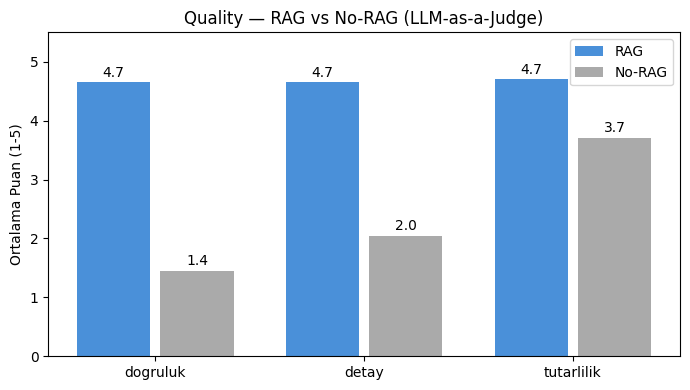

In [8]:
# Quality sonuçlarını görselleştir (full run sonrası)
if 'quality_results' in dir() and quality_results['n_questions'] > 1:
    kriterler = ['dogruluk', 'detay', 'tutarlilik']
    rag_vals = [quality_results['rag_scores'][k] or 0 for k in kriterler]
    nr_vals = [quality_results['no_rag_scores'][k] or 0 for k in kriterler]

    x = range(len(kriterler))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar([i - 0.2 for i in x], rag_vals, width=0.35, label='RAG', color='#4a90d9')
    ax.bar([i + 0.2 for i in x], nr_vals, width=0.35, label='No-RAG', color='#aaaaaa')
    ax.set_xticks(list(x))
    ax.set_xticklabels(kriterler)
    ax.set_ylim(0, 5.5)
    ax.set_ylabel('Ortalama Puan (1-5)')
    ax.set_title('Quality — RAG vs No-RAG (LLM-as-a-Judge)')
    ax.legend()
    for i, (r, n) in enumerate(zip(rag_vals, nr_vals)):
        ax.text(i - 0.2, r + 0.1, f'{r:.1f}', ha='center', fontsize=10)
        ax.text(i + 0.2, n + 0.1, f'{n:.1f}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

---
## 3. Sonuç Özeti

In [9]:
print("=" * 50)
print("cmyLLMz — Faz 13 Evaluation Özeti")
print("=" * 50)
print(f"\nRETRIEVAL (top-{retrieval_results['top_k']})")
print(f"  Hit Rate    : {retrieval_results['hit_rate']:.1%}   <- ANA METRİK")
print(f"  Recall@k    : {retrieval_results['avg_recall']:.1%}")
print(f"  Precision@k : {retrieval_results['avg_precision']:.1%}")

if 'quality_results' in dir():
    print(f"\nQUALITY (LLM-as-a-Judge, n={quality_results['n_questions']})")
    for k in ['dogruluk', 'detay', 'tutarlilik']:
        r = quality_results['rag_scores'][k]
        n = quality_results['no_rag_scores'][k]
        print(f"  {k:12s}: RAG={r}/5  No-RAG={n}/5")

print("\nHedefler:")
print("  Retrieval Hit Rate > %85")
print("  RAG doğruluk > No-RAG doğruluk")
print("=" * 50)

cmyLLMz — Faz 13 Evaluation Özeti

RETRIEVAL (top-5)
  Hit Rate    : 100.0%   <- ANA METRİK
  Recall@k    : 76.4%
  Precision@k : 17.3%

QUALITY (LLM-as-a-Judge, n=20)
  dogruluk    : RAG=4.65/5  No-RAG=1.45/5
  detay       : RAG=4.65/5  No-RAG=2.05/5
  tutarlilik  : RAG=4.7/5  No-RAG=3.7/5

Hedefler:
  Retrieval Hit Rate > %85
  RAG doğruluk > No-RAG doğruluk
